## Preparation cell
This cell imports dependencies and loads traning data set

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Label
from sklearn.impute import SimpleImputer
from sklearn import preprocessing 
# Load the Titanic dataset
df = pd.read_csv('train.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())


Dataset shape: (891, 12)

First few rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0     

The following cell shows info for the dataset, such as data types and number of data

In [5]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


The training data is missing some values, this cell displays them.

In [6]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Translates the sex category with one hot encoding, which makes sorting easier later

In [11]:
categorical_cols = ['Sex']
cat_df = df[categorical_cols].copy()

from sklearn.preprocessing import OneHotEncoder 
encoder = OneHotEncoder(sparse_output=False) 
encoded_data = encoder.fit_transform(cat_df) 
encoded_cat_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))
print("Original categorical data:") 
print(cat_df.head()) 
print("\nAfter one-hot encoding:") 
print(encoded_cat_df.head()) 


Original categorical data:
      Sex
0    male
1  female
2  female
3  female
4    male

After one-hot encoding:
   Sex_female  Sex_male
0         0.0       1.0
1         1.0       0.0
2         1.0       0.0
3         1.0       0.0
4         0.0       1.0


In [12]:
categorical_cols = ['Pclass'] 
cat_df = df[categorical_cols].copy() 
# Label encoding for ordinal categories 
from sklearn.preprocessing import OrdinalEncoder 
ordinal_encoder = OrdinalEncoder(categories=[['1', '2', '3']])
cat_df['Pclass_encoded'] = ordinal_encoder.fit_transform(cat_df[['Pclass']]) 

print("\nAfter OrdinalEncoder encoding:") 
print(cat_df.head(10)) 



After OrdinalEncoder encoding:
   Pclass  Pclass_encoded
0       3             2.0
1       1             0.0
2       3             2.0
3       1             0.0
4       3             2.0
5       3             2.0
6       1             0.0
7       3             2.0
8       3             2.0
9       2             1.0


In [13]:
categorical_cols = ['Embarked'] 
cat_df = df[categorical_cols].copy() 
# Use survival as target variable 
cat_df['Survived'] = df['Survived'] 
# Calculate mean survival for each embarked port
embarked_means = cat_df.groupby('Embarked')['Survived'].mean() 
print(embarked_means) 



Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [14]:
categorical_cols = ['Embarked']
cat_df = df[categorical_cols].copy()
# Use survival as target variable
cat_df['Survived'] = df['Survived']
# Calculate mean survival for each embarked port
embarked_means = cat_df.groupby('Embarked')['Survived'].mean()
print(f"Mean survival rate by port:\n{embarked_means}\n")
cat_df['Embarked_encoded'] = cat_df['Embarked'].map(embarked_means)
print("Target encoding for Embarked:")
print(cat_df.head())

Mean survival rate by port:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

Target encoding for Embarked:
  Embarked  Survived  Embarked_encoded
0        S         0          0.336957
1        C         1          0.553571
2        S         1          0.336957
3        S         1          0.336957
4        S         0          0.336957


In [15]:
embarked_freq = cat_df['Embarked'].value_counts(normalize=True)

print(f"Frequency of each port:\n{embarked_freq}\n")
cat_df['Embarked_freq'] = cat_df['Embarked'].map(embarked_freq)
print("Frequency encoding for Embarked:")
print(cat_df[['Embarked', 'Embarked_freq']].head())

Frequency of each port:
Embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64

Frequency encoding for Embarked:
  Embarked  Embarked_freq
0        S       0.724409
1        C       0.188976
2        S       0.724409
3        S       0.724409
4        S       0.724409


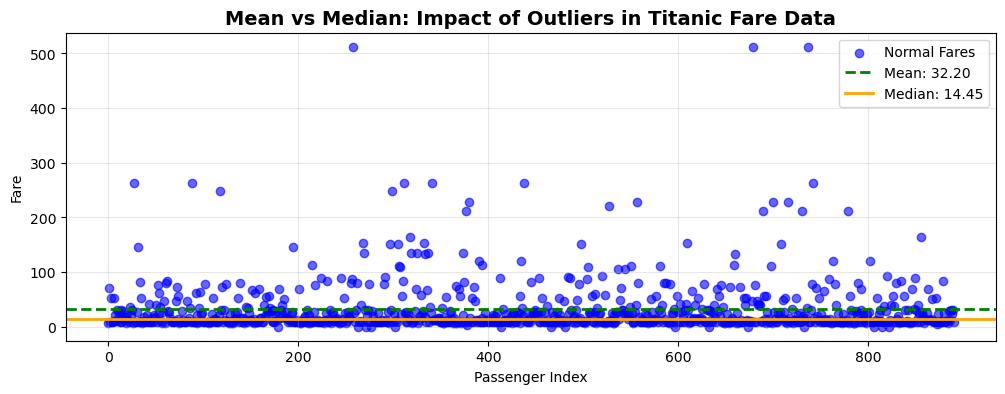

In [17]:
plt.figure(figsize=(12, 4)) 


fare_data = df['Fare'].dropna()
plt.scatter(range(len(fare_data)), fare_data, color='blue', alpha=0.6, label='Normal Fares')
# Add mean and median lines
mean_fare = fare_data.mean()
median_fare = fare_data.median()
plt.axhline(y=mean_fare, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_fare:.2f}')
plt.axhline(y=median_fare, color='orange', linestyle='-', linewidth=2, label=f'Median: {median_fare:.2f}')
plt.title('Mean vs Median: Impact of Outliers in Titanic Fare Data', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Index')
plt.ylabel('Fare')
plt.legend()
plt.grid(True, alpha=0.3)

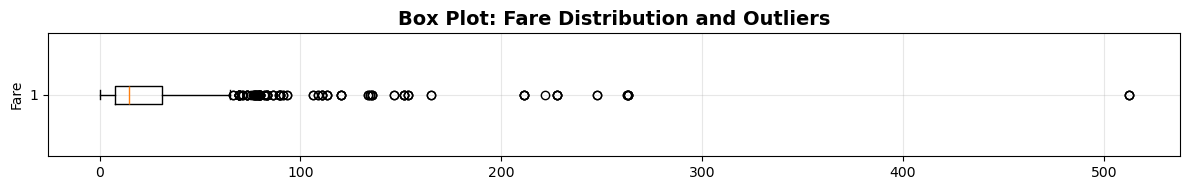

Fare Statistics:
Mean: 32.20
Median: 14.45
Difference: 17.75
Outliers (fares >= 100): 53 passengers


In [19]:
plt.figure(figsize=(12, 2))
plt.boxplot(fare_data, vert=False)
plt.title('Box Plot: Fare Distribution and Outliers', fontsize=14, fontweight='bold')
plt.ylabel('Fare')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Fare Statistics:")
print(f"Mean: {mean_fare:.2f}")
print(f"Median: {median_fare:.2f}")
print(f"Difference: {abs(mean_fare - median_fare):.2f}")
outliers = fare_data[fare_data >= 100] # Expensive tickets
print(f"Outliers (fares >= 100): {len(outliers)} passengers")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Label
from sklearn.impute import SimpleImputer
# Load the Titanic dataset
df = pd.read_csv('train.csv') 
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item
0,1,0,3,Braund Mr Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S,21171,A/5
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC
2,3,1,3,Heikkinen Miss Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3101282,STON/O2.
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE
4,5,0,3,Allen Mr William Henry,male,35.0,0,0,373450,8.0500,NaN,S,373450,NONE
